# Preprocessing lima dataset bahan pewangi
**Input:** SMILES satu molekul. **Target:** beberapa label aroma per molekul.
Sumber: GoodScents, IFRA 2019, Leffingwell, Arctander 1960, Sigma-Aldrich 2014.
Notebook ini benar-benar menjalankan fungsi preprocessing yang dipakai runner ML.
Fokusnya bahan pewangi; arsip terpilih juga memuat flavor, sehingga bukan daftar parfum murni.

Jalankan semua sel dari atas. Pilih Python environment proyek. Download hanya diperlukan jika cache belum tersedia.
Notebook tidak melatih model dan tidak menilai skor test.

## 1. Persiapan
Lokasi proyek ditemukan dari folder kerja. Konfigurasi sumber, fitur, dan seed dibaca dari satu file.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'alignment/perfume_config.json').exists()), None)
if ROOT is None:
    raise RuntimeError('Buka notebook dari folder repository ML.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from alignment import perfume_data as prep
from alignment.experiments import preflight
config = prep.load_config()
OUTPUT = prep.OUTPUT
FIGURES = ROOT / 'reports/perfume_five_20260910/figures'
FIGURES.mkdir(parents=True, exist_ok=True)
display(pd.DataFrame({'sumber': list(config['sources']), 'folder': [v['behavior'].split('/')[0] for v in config['sources'].values()]}))
print('Revision:', config['revision'])


Revision: 8054ea98ed675005ec10e67359902f500e4911b0


,sumber,folder
0,goodscents,goodscents
1,ifra,ifra_2019
2,leffingwell,leffingwell
3,arctander,arctander_1960
4,sigma,sigma_2014


## 2. Load Data
Molecules berisi struktur; stimuli menghubungkan identitas; behavior berisi aroma. Checksum memeriksa agar isi cache tidak berubah.

In [2]:
tables, source_manifest = prep.load_sources(config)
inventory = pd.DataFrame([{'tabel': k, 'baris': len(v), 'kolom': len(v.columns)} for k,v in tables.items()])
display(inventory)
assert len(tables) == 15
assert all(k.split('_')[0] in prep.REQUIRED_SOURCES for k in tables)


,tabel,baris,kolom
0,goodscents_molecules,4565,5
1,goodscents_stimuli,4626,5
2,goodscents_behavior,4626,2
3,ifra_molecules,1060,5
4,ifra_stimuli,1060,2
5,ifra_behavior,1146,4
6,leffingwell_molecules,3522,5
7,leffingwell_stimuli,3522,7
8,leffingwell_behavior,3522,114
9,arctander_molecules,2751,5


## 3. Cek Data Kosong
Nilai kosong pada label tambahan dapat wajar. Struktur yang hilang tidak ditebak atau diganti nol.

In [3]:
missing = pd.DataFrame([{'tabel': name, 'kolom': column, 'kosong': int(frame[column].isna().sum())}
                        for name,frame in tables.items() for column in frame
                        if frame[column].isna().any()])
display(missing.sort_values('kosong', ascending=False).head(20))


,tabel,kolom,kosong
2,goodscents_stimuli,Solvent,2776
10,arctander_stimuli,CAS,2432
1,goodscents_stimuli,Concentration %,489
11,arctander_behavior,Labels,275
6,leffingwell_stimuli,cas,154
4,leffingwell_molecules,IUPACName,36
5,leffingwell_stimuli,IUPACName,36
0,goodscents_molecules,IUPACName,6
3,goodscents_behavior,Descriptors,4
9,arctander_stimuli,ChemicalName,3


## 4. Bersihkan dan Gabungkan
Hubungkan identitas secara eksplisit, periksa SMILES dengan RDKit, keluarkan struktur tidak valid atau multifragmen.
Duplikat SMILES kanonik digabung dengan union label dan asal sumber tetap disimpan.
Istilah mengikuti 184 deskriptor teramati IFRA pada snapshot ini. Sinonim hanya dipetakan lewat daftar eksplisit.
Istilah yang belum cocok dicatat, bukan diterjemahkan dengan tebakan. Baris yang tidak punya label cocok dikeluarkan.

In [4]:
records, taxonomy, audit, rejected, provenance, unmapped, mappings = prep.merge_sources(tables, config)
source_audit = pd.DataFrame(audit['sources']).T
display(source_audit)
display(records.head())
print('Molekul unik:', len(records), '| Kamus IFRA:', len(taxonomy))
print('SMILES duplikat:', records.smiles.duplicated().sum())
display(pd.DataFrame(rejected).groupby(['source','reason']).size().rename('jumlah').reset_index())


Molekul unik: 6686 | Kamus IFRA: 184
SMILES duplikat: 0


,rows,missing_identity,invalid_smiles,multifragment,empty_labels,unmapped_labels,invalid_behavior,accepted
goodscents,4626,0,0,183,4,335,0,4104
ifra,1146,0,0,28,0,0,0,1118
leffingwell,3522,0,0,0,0,114,0,3408
arctander,3102,278,0,102,209,73,0,2440
sigma,941,204,0,0,0,30,0,707


,source_row,smiles,labels,sources
0,0,BrC=Cc1ccccc1,"[floral, green, hyacinth, leafy]","[arctander, goodscents]"
1,1,C#CC(C)(O)CCC=C(C)C,"[dry, musk like, sweet, waxy, woody]",[goodscents]
2,2,C#CC(C)CO,"[ethereal, green]",[arctander]
3,3,C#CC1(C(=O)OC)CCCCC1,"[green, herbal]",[arctander]
4,4,C#CC1(OC(C)=O)CCCCC1,"[dry, hay, herbal, oak, woody]","[goodscents, ifra]"


,source,reason,jumlah
0,arctander,empty_labels,209
1,arctander,missing_identity,278
2,arctander,multifragment,102
3,arctander,unmapped_labels,73
4,goodscents,empty_labels,4
5,goodscents,multifragment,183
6,goodscents,unmapped_labels,335
7,ifra,multifragment,28
8,leffingwell,unmapped_labels,114
9,sigma,missing_identity,204


## 5. Visualisasi Pembersihan
Jumlah di sini adalah baris sumber sebelum penggabungan duplikat, bukan jumlah molekul unik.

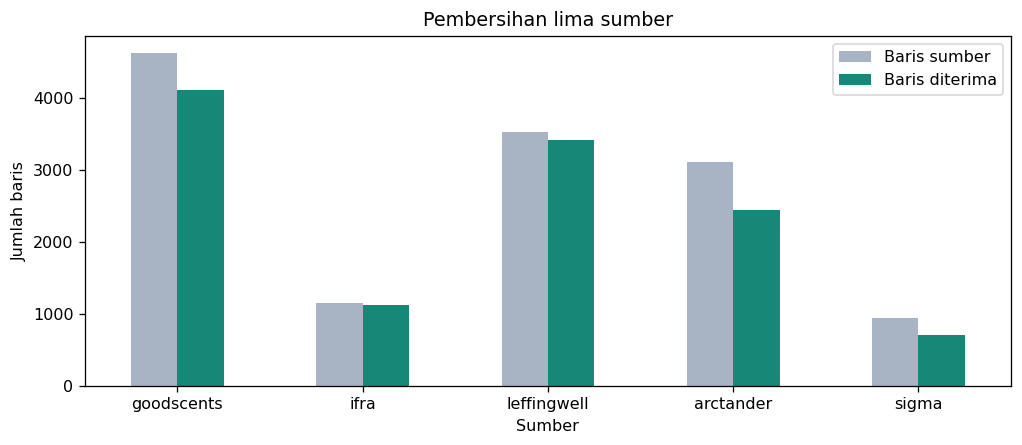

,source,descriptor,count
0,leffingwell,meaty,218
1,leffingwell,winey,174
2,leffingwell,caramellic,161
3,goodscents,meaty,158
4,arctander,winey,143
5,goodscents,caramellic,131
6,goodscents,odorless,112
7,goodscents,camphoreous,110
8,arctander,musky,104
9,goodscents,winey,90


,source,raw_descriptor,label,method,count
2,arctander,animal,animal like,alias,73
65,goodscents,animal,animal like,alias,93
70,goodscents,balsam,balsamic,alias,26
79,goodscents,butter,buttery,alias,1
114,goodscents,flower,floral,alias,7
115,goodscents,flowers,floral,alias,1
118,goodscents,fruit,fruity,alias,3
132,goodscents,herb,herbal,alias,1
133,goodscents,herbaceous,herbal,alias,1
163,goodscents,mint,minty,alias,1


In [5]:
fig, ax = plt.subplots(figsize=(9,4))
source_audit[['rows','accepted']].rename(columns={'rows':'Baris sumber','accepted':'Baris diterima'}).plot.bar(ax=ax,color=['#a8b4c4','#178878'])
ax.set(title='Pembersihan lima sumber',xlabel='Sumber',ylabel='Jumlah baris')
ax.tick_params(axis='x',rotation=0)
fig.tight_layout(); fig.savefig(FIGURES/'source_attrition.png',dpi=160)
display(fig); plt.close(fig)
display(unmapped.head(15))
display(mappings[mappings.method=='alias'].head(15))


## 6. Label Encoding dan Pembagian Data
Target dibuat multi-hot: 1 = aroma tercatat, 0 = tidak tercatat, bukan bukti aroma tidak ada.
Split sekitar 80:20 menggunakan stratifikasi multi-label, seed 42; ukuran akhir dapat sedikit berbeda.
Label dipilih hanya dari training: minimal 30 positif dan 2 negatif. **Tidak dibatasi 25 label.**
CV per label maksimal lima fold; indeks sama dipakai semua kondisi.
Baris yang menjadi semua nol setelah seleksi tetap disimpan untuk mencegah perubahan kohort diam-diam.

In [6]:
target, labels, split, support, selection = prep.encode_and_split(records, taxonomy, config)
print('Shape target:', target.shape)
print('Training:', len(split['train']), '| Test:', len(split['test']), '| Label terpilih:', len(labels))
display(support.sort_values('train_positive',ascending=False).head(20))
print('Label tidak terpilih:', int((~selection.selected).sum()))
print('Training semua nol:', int((target[split['train']].sum(axis=1)==0).sum()))
assert not set(records.iloc[split['train']].smiles) & set(records.iloc[split['test']].smiles)


Shape target: (6686, 109)
Training: 5318 | Test: 1368 | Label terpilih: 109
Label tidak terpilih: 75
Training semua nol: 12


,label,train_positive,train_negative,folds
38,fruity,1998,3320,5
45,green,1655,3663,5
36,floral,1449,3869,5
97,sweet,1276,4042,5
47,herbal,1017,4301,5
108,woody,854,4464,5
34,fatty,611,4707,5
69,oily,553,4765,5
94,spicy,510,4808,5
37,fresh,506,4812,5


## 7. Distribusi Label Training
Grafik menampilkan 25 label teratas agar terbaca; model tetap memakai seluruh label terpilih.

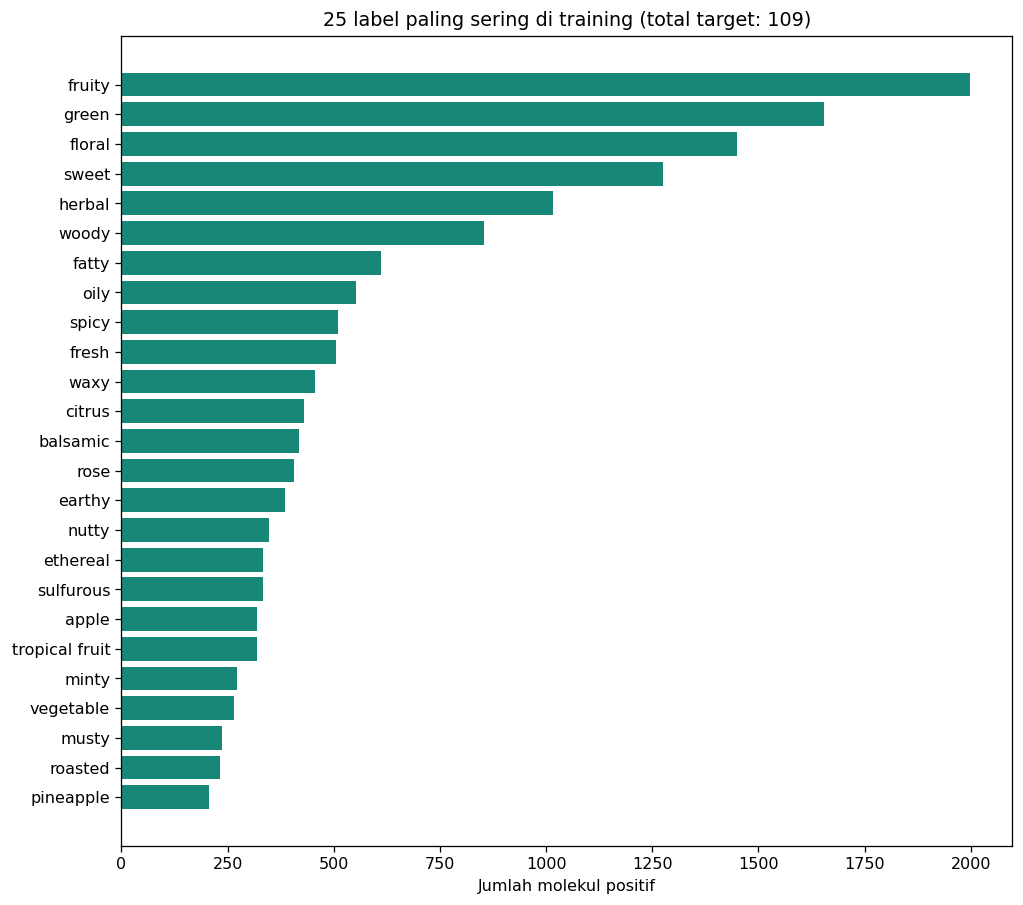

In [7]:
top = support.nlargest(25,'train_positive').sort_values('train_positive')
fig, ax = plt.subplots(figsize=(9,8))
ax.barh(top.label,top.train_positive,color='#178878')
ax.set(title=f'25 label paling sering di training (total target: {len(labels)})',xlabel='Jumlah molekul positif')
fig.tight_layout(); fig.savefig(FIGURES/'training_labels.png',dpi=160)
display(fig); plt.close(fig)


## 8. Ekstraksi RDKit
Morgan radius 2, 1.024 bit, tanpa kiralitas. Lima fitur tambahan: MolWt, MolLogP, NumHDonors, NumHAcceptors, TPSA.
Kedua blok dihitung dari SMILES kanonik yang sama. Hasil yang tidak finite menghentikan proses agar bisa diperiksa.
A/C memakai Morgan; B/D memakai Morgan + lima fitur. Tidak ada scaling yang dipelajari dari test.

In [8]:
morgan, descriptors = prep.extract_features(records, config)
print('Morgan:', morgan.shape, '| Deskriptor:', descriptors.shape)
print('Fitur gabungan:', (len(records), morgan.shape[1]+descriptors.shape[1]))
assert np.isfinite(descriptors).all()
display(pd.DataFrame(descriptors[split['train']],columns=config['features']['descriptors']).describe().round(3))


Morgan: (6686, 1024) | Deskriptor: (6686, 5)
Fitur gabungan: (6686, 1029)


,MolWt,MolLogP,NumHDonors,NumHAcceptors,TPSA
count,5318.000,5318.000,5318.000,5318.000,5318.000
mean,179.079,2.721,0.306,1.867,25.429
std,59.600,1.367,0.717,1.236,19.490
min,27.026,-15.231,0.000,0.000,0.000
25%,143.484,1.905,0.000,1.000,17.070
50%,172.268,2.654,0.000,2.000,26.300
75%,206.285,3.466,1.000,2.000,26.300
max,1701.206,17.714,25.000,46.000,777.980


## 9. Simpan dan Verifikasi Dataset ML
Jika build belum ada, simpan melalui fungsi produksi. Build yang sudah ada tidak ditimpa.
Periksa registry label, bentuk matriks, checksum, dan fold. Tidak membuka prediksi atau skor test.

In [9]:
if not OUTPUT.exists():
    prep.prepare(OUTPUT, offline=True)
meta, protocol = preflight(OUTPUT)
assert meta['labels'] == labels
assert meta['source_names'] == list(config['sources'])
assert json.loads((OUTPUT/'splits.json').read_text()) == split
with np.load(OUTPUT/'train.npz',allow_pickle=False) as saved:
    assert np.array_equal(saved['truth'],target[split['train']])
    assert np.array_equal(saved['morgan'],morgan[split['train']])
    assert np.array_equal(saved['descriptors'],descriptors[split['train']])
print('PASS: notebook dan dataset ML konsisten.')
print('Output:', OUTPUT)


PASS: notebook dan dataset ML konsisten.
Output: C:\Users\ACER\Documents\Marvel\Skripsi\Project Skripsi\Perfume-MultiLabel-Classifier\data\builds\perfume-five-v1


## 10. Lanjut Eksperimen
Pada PC kampus, jalankan RUN_PERFUME_FIVE.cmd dari folder repository.
Runner melatih XGBoost lalu LightGBM, masing-masing kondisi A–D, dan menyimpan model serta hasil per label.
Enam metrik: accuracy biner, AUROC, AUPRC (Average Precision), specificity, precision, recall.
Perbandingan adil adalah baseline vs modifikasi pada lima sumber yang sama.
Dataset berubah dari Suh, sehingga skor artikel Suh bukan pembanding langsung.

**Referensi tambahan:** [Cao & Ling (2022)](https://doi.org/10.3390/app12199716) mendukung konteks penggunaan ML untuk parfum. Metodenya electronic nose, sehingga berbeda dari prediksi SMILES pada notebook ini.